Dữ liệu sẵn sàng so sánh: (18021, 4007)
 Đang chạy thử nghiệm với min_support = 0.05...
 Đang chạy thử nghiệm với min_support = 0.03...
 Đang chạy thử nghiệm với min_support = 0.02...
 Đang chạy thử nghiệm với min_support = 0.015...

 BẢNG KẾT QUẢ SO SÁNH:


,min_support,Apriori_Time (s),FPGrowth_Time (s),Itemsets_Count
0,0.050,0.156437,4.489222,34
1,0.030,0.948781,6.726727,145
2,0.020,3.829294,17.561229,400
3,0.015,13.927670,39.794468,755


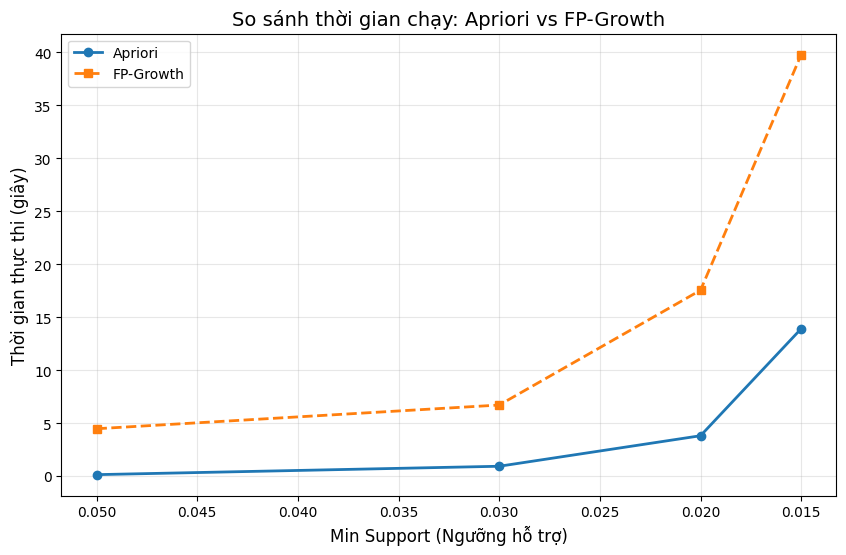

In [2]:
import warnings
# Tắt cảnh báo DeprecationWarning
warnings.filterwarnings("ignore", category=DeprecationWarning) 

import sys
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from apriori_library import AssociationRulesMiner, FPGrowthMiner

basket_bool = pd.read_parquet('../data/processed/basket_bool.parquet')
print(f"Dữ liệu sẵn sàng so sánh: {basket_bool.shape}")

def compare_algorithms(data, min_supports):
    results = []

    for support in min_supports:
        print(f" Đang chạy thử nghiệm với min_support = {support}...")
        
        # --- 1. Apriori ---
        ap_miner = AssociationRulesMiner(data)
        start_time = time.time()
        ap_fi = ap_miner.mine_frequent_itemsets(min_support=support)
        ap_time = time.time() - start_time
        
        # --- 2. FP-Growth ---
        fp_miner = FPGrowthMiner(data)
        start_time = time.time()
        fp_fi = fp_miner.mine_frequent_itemsets(min_support=support)
        fp_time = time.time() - start_time
        
        # Kiểm tra số lượng itemset (phải bằng nhau về lý thuyết)
        assert len(ap_fi) == len(fp_fi), f"Lỗi: Số lượng itemset không khớp tại support {support}"
        
        results.append({
            'min_support': support,
            'Apriori_Time (s)': ap_time,
            'FPGrowth_Time (s)': fp_time,
            'Itemsets_Count': len(ap_fi)
        })
    
    return pd.DataFrame(results)

# Danh sách các ngưỡng support cần test (giảm dần để tăng độ khó)
# Lưu ý: Nếu máy yếu, đừng để support quá thấp (dưới 0.01) vì Apriori sẽ chạy rất lâu
supports_to_test = [0.05, 0.03, 0.02, 0.015] 

df_comparison = compare_algorithms(basket_bool, supports_to_test)

print("\n BẢNG KẾT QUẢ SO SÁNH:")
display(df_comparison)

plt.figure(figsize=(10, 6))

# Vẽ đường Apriori
plt.plot(df_comparison['min_support'], df_comparison['Apriori_Time (s)'], 
         marker='o', linestyle='-', linewidth=2, label='Apriori')

# Vẽ đường FP-Growth
plt.plot(df_comparison['min_support'], df_comparison['FPGrowth_Time (s)'], 
         marker='s', linestyle='--', linewidth=2, label='FP-Growth')

plt.title('So sánh thời gian chạy: Apriori vs FP-Growth', fontsize=14)
plt.xlabel('Min Support (Ngưỡng hỗ trợ)', fontsize=12)
plt.ylabel('Thời gian thực thi (giây)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Đảo ngược trục X để support giảm dần từ trái qua phải (thể hiện độ phức tạp tăng dần)
plt.gca().invert_xaxis()

plt.show()